In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os

rngs = []
for base, dirs, files in os.walk("D:/rngs_cross_epoch/"):
	if "trainUval" not in base:
		continue
	 
	tag = base.strip("/").split("/")[-2]
	for file in files:
		if file.endswith(".txt"):
			e = int(file.split("_")[-3].split("e")[1])
			rng = nx.read_adjlist(os.path.join(base, file))
			avg_degree = sum(dict(rng.degree()).values()) / rng.number_of_nodes()
			rngs.append((tag, e, avg_degree))


D:/rngs_cross_epoch/
D:/rngs_cross_epoch/densenet_cifar
D:/rngs_cross_epoch/densenet_cifar\train
D:/rngs_cross_epoch/densenet_cifar\val
D:/rngs_cross_epoch/densenet_cifar\trainUval
D:/rngs_cross_epoch/resnet_cifar
D:/rngs_cross_epoch/resnet_cifar\train
D:/rngs_cross_epoch/resnet_cifar\val
D:/rngs_cross_epoch/resnet_cifar\trainUval


In [2]:
len(rngs)

402

In [3]:
df = pd.DataFrame(rngs, columns=["tag", "epoch", "degree"])
df = df.sort_values(["tag", "epoch"]).reset_index(drop=True)
df


,tag,epoch,degree
0,rngs_cross_epoch,0,38.646833
1,rngs_cross_epoch,0,44.824167
2,rngs_cross_epoch,1,48.486967
3,rngs_cross_epoch,1,41.310733
4,rngs_cross_epoch,2,47.182833
...,...,...,...
397,rngs_cross_epoch,198,33.667267
398,rngs_cross_epoch,199,37.347933
399,rngs_cross_epoch,199,33.421667
400,rngs_cross_epoch,200,37.528400


In [4]:
print("=== Degree stats per tag ===")
print(df.groupby("tag")["degree"].describe())
print()
print("=== Overall degree stats ===")
print(df["degree"].describe())


=== Degree stats per tag ===
                  count       mean       std      min        25%        50%  \
tag                                                                           
rngs_cross_epoch  402.0  39.464817  3.519277  33.3667  36.623333  39.248717   

                        75%        max  
tag                                     
rngs_cross_epoch  41.443358  49.303667  

=== Overall degree stats ===
count    402.000000
mean      39.464817
std        3.519277
min       33.366700
25%       36.623333
50%       39.248717
75%       41.443358
max       49.303667
Name: degree, dtype: float64


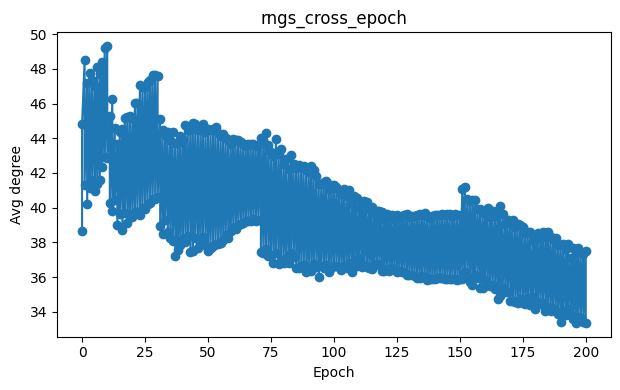

In [5]:
tags = df["tag"].unique()
ncols = 2
nrows = (len(tags) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), squeeze=False)

for i, tag in enumerate(sorted(tags)):
    ax = axes[i // ncols][i % ncols]
    sub = df[df["tag"] == tag].sort_values("epoch")
    ax.plot(sub["epoch"], sub["degree"], marker="o")
    ax.set_title(tag)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Avg degree")

# Hide any unused subplots
for j in range(len(tags), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.tight_layout()
plt.show()
